# 05b - So sanh Tracking: ByteTrack vs BoT-SORT vs OC-SORT vs Deep OC-SORT vs FastTracker vs TrackTrack

**3 thay doi so voi ban truoc:**

1. **Chay tren GPU** (thay vi CPU) - truyen tuong minh `device=0` vao `model.track()`,
   khong de ultralytics tu quyet dinh. Neu may khong co GPU, cell kiem tra o duoi se
   canh bao ro va tu dong roi ve CPU thay vi loi thang.
2. **Detector nang tu `yolov8n` len `yolov8s`** - lan chay CPU truoc voi `yolov8n` chi
   bat duoc ~23% ground truth (18581 box that, chi match ~4200) du da ha `conf=0.15`.
   Day la gioi han nang luc cua ban `nano`, khong phai loi nguong loc - nang model de
   co nen tang cong bang hon truoc khi so sanh 6 tracker.
3. **Them phan do FPS** (Buoc 3b) - do THOI GIAN THUC ca vong lap detector+tracker cho
   tung tracker (khong chi dua vao `r.speed`, vi so do KHONG tinh chi phi rieng cua
   thuat toan tracking nhu ReID trong Deep OC-SORT/TrackTrack).

**Thiet ke thi nghiem khong doi:** co dinh detector cho ca 6 tracker (`yolov8s`,
chay tren GPU), chi doi thuat toan tracking, de so sanh cong bang.

**Cap nhat:** khong doi sang SCRFD cho thi nghiem chinh (ly do o Phu luc cuoi notebook).
Pipeline Buoc 1-4 giu nguyen YOLOv8s + `model.track(tracker=...)`.

**Ca 6 tracker deu tich hop SAN trong `ultralytics` (tu ban v8.4.63 tro len)** - chi
doi ten file YAML o tham so `tracker=`, khong can cai them package/model rieng nao:

| Tracker | File config | Dac diem chinh |
|---|---|---|
| ByteTrack | `bytetrack.yaml` | Cần baseline nhanh nhất, đơn giản nhất? → ByteTrack (không ReID, không bù chuyển động camera, overhead tối thiểu). |
| BoT-SORT | `botsort.yaml` | Cảnh quay cầm tay, drone, hoặc camera di động? → BoT-SORT (mặc định; thêm bù chuyển động camera và ReID tùy chọn). |
| OC-SORT | `ocsort.yaml` | Chuyển động phi tuyến tính (thể thao, khiêu vũ, rẽ đột ngột) và không cần ReID? → OC-SORT (hiệu chỉnh theo quan sát mà không mất chi phí về diện mạo). |
| Deep OC-SORT | `deepocsort.yaml` | Các cảnh quay camera di động đông đúc nơi hoán đổi ID là vấn đề chính? → Deep OC-SORT hoặc TrackTrack (cả hai đều thêm hợp nhất diện mạo thích ứng; TrackTrack cũng thêm liên kết đa tín hiệu và triệt tiêu trùng lặp ID). |
| FastTracker | `fasttrack.yaml` | ByteTrack + xu ly che khuat (occlusion-aware), Thường xuyên chồng lấp một phần trong thời gian thực, không có ngân sách cho ReID? |
| TrackTrack | `tracktrack.yaml` | Association da tieu chi (IoU+ReID+conf+goc), manh nhat cho canh dong nguoi che khuat |

**Thiet ke thi nghiem:** co dinh detector la **YOLOv8n** cho ca 6 lan chay - chi doi
thuat toan tracking, khong doi detector, de so sanh cong bang. Dung config MAC DINH
cua tung tracker (khong bat `with_reid`) de danh gia "ngay khi dung ra, khong chinh
tay" - neu muon thu nghiem sau hon co the bat ReID rieng cho BoT-SORT/Deep OC-SORT/
TrackTrack sau (xem ghi chu cuoi notebook).

In [ ]:
%pip install opencv-python numpy pandas matplotlib

  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/21/f0/9fa6e85cb10c8eb36a0222d27e50fe381b86ce49a55446bf39f491727564/opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata
  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/65/66/53f31807a48a750f9d748da273bc3fcedd12b27ff1f3e373bfec55ef2dc0/numpy-2.5.1-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/70/b5/d2d3e9ae73362ba4229651b0ee1455cf78073a1ce585f6ff693782ce263e/pandas-3.0.5-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/88/89/56649bbaa2fd12e20f3be03dbcc135b0c8676d88bac17977599e3eb442a0/matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     -------------------- ------------------- 41.0/80.3 kB 1.9 MB/s eta 0:00:01
  

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sys

print("Python đang chạy notebook:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python đang chạy notebook:
d:\Code\Face recognition security system\.venv_gpu\Scripts\python.exe

Python version:
3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]


In [1]:
# ===== CELL 1: Thiet lap duong dan =====
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = r'D:\Code\Face recognition security system'
AI_DIR = os.path.join(BASE_DIR, 'ai')
BENCHMARK_DIR = os.path.join(AI_DIR, 'dataset', 'benchmarks')
RESULTS_DIR = os.path.join(AI_DIR, 'models', 'tracker_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

MOT_SEQUENCE = 'MOT17-02-FRCNN'
mot_seq_dir = os.path.join(BENCHMARK_DIR, MOT_SEQUENCE)
img_dir = os.path.join(mot_seq_dir, 'img1')
gt_path = os.path.join(mot_seq_dir, 'gt', 'gt.txt')

assert os.path.exists(img_dir) and os.path.exists(gt_path), (
    f"Chua thay du lieu MOT17 tai {mot_seq_dir}"
)
print("Da tim thay du lieu MOT17 tai:", mot_seq_dir)


Da tim thay du lieu MOT17 tai: D:\Code\Face recognition security system\ai\dataset\benchmarks\MOT17-02-FRCNN


In [2]:
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("PyTorch CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]
PyTorch: 2.7.1+cu118
PyTorch CUDA: 11.8
CUDA available: True
CUDA device count: 1
GPU: NVIDIA GeForce GTX 1650


In [ ]:
!pip install -U -q ultralytics motmetrics

In [3]:
# ===== CELL 2: Cai dat / nang cap thu vien + kiem tra GPU =====
import ultralytics
print("ultralytics version:", ultralytics.__version__)

if not hasattr(np, 'asfarray'):
    np.asfarray = lambda a, dtype=float: np.asarray(a, dtype=dtype)

import torch

CUDA_OK = torch.cuda.is_available()
TRACK_DEVICE = 0 if CUDA_OK else 'cpu'  # 0 = GPU dau tien, dung tuong minh thay vi de auto

print(f"\nTorch version: {torch.__version__}")
print(f"CUDA available: {CUDA_OK}")
if CUDA_OK:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("KHONG thay GPU - se tu dong roi ve CPU, FPS do duoc se thap hon nhieu so voi GPU.")

print(f"\n=> Se chay tren device={TRACK_DEVICE} ({'GPU' if CUDA_OK else 'CPU'})")


ultralytics version: 8.4.108

Torch version: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce GTX 1650
VRAM: 4.3 GB

=> Se chay tren device=0 (GPU)


## Buoc 1 - Dung anh MOT17 thanh video tam + doc ground truth

In [4]:
# ===== CELL 3: Dung sequence anh thanh 1 video tam =====

def build_video_from_image_sequence(image_dir, output_video_path, fps=25):
    frame_files = sorted(f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png')))
    assert frame_files, f"Khong tim thay anh nao trong {image_dir}"

    first_img = cv2.imread(os.path.join(image_dir, frame_files[0]))
    h, w = first_img.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))
    for fname in frame_files:
        writer.write(cv2.imread(os.path.join(image_dir, fname)))
    writer.release()
    return len(frame_files), w, h


temp_video_path = os.path.join(RESULTS_DIR, f'{MOT_SEQUENCE}_temp1_trackingcmp.mp4')
n_frames, seq_w, seq_h = build_video_from_image_sequence(img_dir, temp_video_path, fps=25)
print(f"Da dung {n_frames} anh ({seq_w}x{seq_h}) thanh video tam: {temp_video_path}")


Da dung 600 anh (1920x1080) thanh video tam: D:\Code\Face recognition security system\ai\models\tracker_results\MOT17-02-FRCNN_temp1_trackingcmp.mp4


In [5]:
# ===== CELL 4: Doc ground truth (chi giu pedestrian, conf==1) =====

gt_cols = ['frame', 'id', 'x', 'y', 'w', 'h', 'conf', 'cls', 'vis']
gt_df = pd.read_csv(gt_path, header=None, names=gt_cols)
gt_df = gt_df[(gt_df['conf'] == 1) & (gt_df['cls'] == 1)]

print(f"Ground truth (sau loc): {len(gt_df)} box qua {gt_df['frame'].nunique()} frame")


Ground truth (sau loc): 18581 box qua 600 frame


## Buoc 2 - Chay tung tracker tren GPU (cung 1 detector) + tinh MOTA/IDF1 + do FPS

`run_tracker()` truyen tuong minh `device=TRACK_DEVICE` vao `model.track()` de bat
buoc chay GPU (neu co), va tra ve them `fps`/`elapsed_sec` do bang dong ho thuc
(wall-clock) BAO QUANH TOAN BO vong lap detector+tracker - phan anh dung chi phi
THEM VAO cua tung thuat toan tracking (Deep OC-SORT/TrackTrack co ReID/association
phuc tap hon se lo ro qua so nay).

In [6]:
# ===== CELL 5: Ham chay 1 tracker cu the tren GPU, tra ve ket qua + FPS =====
from ultralytics import YOLO

PERSON_CLASS_ID = 0
DETECTOR_MODEL = 'yolov8s.pt'  # NANG tu yolov8n - xem ly do o markdown dau notebook


def run_tracker(tracker_config: str, video_path: str, conf: float = 0.1,
                 model_name: str = DETECTOR_MODEL, device=TRACK_DEVICE):
    """Chay detector CO DINH (model_name) tren device (GPU neu co) voi 1 tracker
    config cu the. Tra ve (track_df, fps, elapsed_sec)."""
    model = YOLO(model_name)

    rows = []
    frame_count = 0

    start_time = time.time()
    results_gen = model.track(
        source=video_path, persist=True, tracker=tracker_config,
        classes=[PERSON_CLASS_ID], conf=conf, device=device,
        stream=True, verbose=False,
    )

    for frame_idx, r in enumerate(results_gen, start=1):  # MOT dung frame bat dau tu 1
        frame_count += 1
        boxes = r.boxes
        if boxes is not None and len(boxes) > 0 and boxes.id is not None:
            xyxy = boxes.xyxy.cpu().numpy()
            track_ids = boxes.id.cpu().numpy().astype(int)
            for (x1, y1, x2, y2), tid in zip(xyxy, track_ids):
                rows.append([frame_idx, int(tid), x1, y1, x2 - x1, y2 - y1])

    if CUDA_OK:
        torch.cuda.synchronize()  # dam bao dem het thoi gian GPU thuc su xu ly xong
    elapsed = time.time() - start_time
    fps = frame_count / elapsed if elapsed > 0 else 0.0

    track_df = pd.DataFrame(rows, columns=['frame', 'id', 'x', 'y', 'w', 'h'])
    return track_df, fps, elapsed


print(f"Da dinh nghia run_tracker() - detector co dinh: {DETECTOR_MODEL}, device: {TRACK_DEVICE}")


Da dinh nghia run_tracker() - detector co dinh: yolov8s.pt, device: 0


In [7]:
# ===== CELL 6: Chay ca 6 tracker, tinh MOTA/IDF1 va FPS =====
import motmetrics as mm

TRACKER_CONFIGS = {
    'ByteTrack':     'bytetrack.yaml',
    'BoT-SORT':      'botsort.yaml',
    'OC-SORT':       'ocsort.yaml',
    'Deep OC-SORT':  'deepocsort.yaml',
    'FastTracker':   'fasttrack.yaml',
    'TrackTrack':    'tracktrack.yaml',
}

comparison_rows = []
per_tracker_track_df = {}

for tracker_name, tracker_config in TRACKER_CONFIGS.items():
    print(f"\n=== Dang chay {tracker_name} ({tracker_config}) ===")
    try:
        track_df, fps, elapsed = run_tracker(tracker_config, temp_video_path, conf=0.1)
    except Exception as e:
        print(f"BO QUA {tracker_name} - loi khi chay: {e}")
        continue

    per_tracker_track_df[tracker_name] = track_df
    print(f"Thu thap duoc {len(track_df)} detection qua {track_df['frame'].nunique()} frame "
          f"trong {elapsed:.1f}s ({fps:.1f} FPS)")

    acc = mm.MOTAccumulator(auto_id=False)
    all_frames = sorted(set(gt_df['frame'].unique().tolist()) | set(track_df['frame'].unique().tolist()))

    for frame in all_frames:
        gt_frame = gt_df[gt_df['frame'] == frame]
        tr_frame = track_df[track_df['frame'] == frame]

        gt_ids = gt_frame['id'].tolist()
        tr_ids = tr_frame['id'].tolist()
        gt_boxes = gt_frame[['x', 'y', 'w', 'h']].values
        tr_boxes = tr_frame[['x', 'y', 'w', 'h']].values

        dists = mm.distances.iou_matrix(gt_boxes, tr_boxes, max_iou=0.5)
        acc.update(gt_ids, tr_ids, dists, frameid=frame)

    mh = mm.metrics.create()
    summary = mh.compute(
        acc,
        metrics=['num_frames', 'mota', 'motp', 'idf1', 'num_switches',
                 'num_false_positives', 'num_misses', 'num_matches'],
        name=tracker_name,
    )

    row = summary.iloc[0].to_dict()
    row['tracker'] = tracker_name
    row['fps'] = round(fps, 2)
    row['elapsed_sec'] = round(elapsed, 1)
    comparison_rows.append(row)

    print(mm.io.render_summary(summary, formatters=mh.formatters, namemap=mm.io.motchallenge_metric_names))

comparison_df = pd.DataFrame(comparison_rows).set_index('tracker')
comparison_csv_path = os.path.join(RESULTS_DIR, 'tracking_comparison_full.csv')
comparison_df.to_csv(comparison_csv_path)

print(f"\nDa luu bang so sanh: {comparison_csv_path}")
comparison_df



=== Dang chay ByteTrack (bytetrack.yaml) ===
Thu thap duoc 6999 detection qua 600 frame trong 100.8s (6.0 FPS)
          num_frames  MOTA  MOTP  IDF1 IDs   FP    FN num_matches
ByteTrack        600 23.4% 0.213 36.2%  64 1296 12878        5639

=== Dang chay BoT-SORT (botsort.yaml) ===
Thu thap duoc 7071 detection qua 600 frame trong 45.7s (13.1 FPS)
         num_frames  MOTA  MOTP  IDF1 IDs   FP    FN num_matches
BoT-SORT        600 23.8% 0.202 35.5%  62 1289 12799        5720

=== Dang chay OC-SORT (ocsort.yaml) ===
Thu thap duoc 6182 detection qua 600 frame trong 17.9s (33.6 FPS)
        num_frames  MOTA  MOTP  IDF1 IDs  FP    FN num_matches
OC-SORT        600 23.1% 0.203 34.7%  85 907 13306        5190

=== Dang chay Deep OC-SORT (deepocsort.yaml) ===
Thu thap duoc 5843 detection qua 600 frame trong 17.4s (34.6 FPS)
             num_frames  MOTA  MOTP  IDF1 IDs  FP    FN num_matches
Deep OC-SORT        600 22.5% 0.198 33.1%  81 793 13531        4969

=== Dang chay FastTracker (fast

,num_frames,mota,motp,idf1,num_switches,num_false_positives,num_misses,num_matches,fps,elapsed_sec
tracker,,,,,,,,,,
ByteTrack,600.0,0.233733,0.212866,0.361845,64.0,1296.0,12878.0,5639.0,5.95,100.8
BoT-SORT,600.0,0.238469,0.201569,0.355372,62.0,1289.0,12799.0,5720.0,13.12,45.7
OC-SORT,600.0,0.230504,0.202789,0.347373,85.0,907.0,13306.0,5190.0,33.60,17.9
Deep OC-SORT,600.0,0.224746,0.198037,0.330904,81.0,793.0,13531.0,4969.0,34.57,17.4
FastTracker,600.0,0.233141,0.215990,0.330806,79.0,1427.0,12743.0,5759.0,36.94,16.2
TrackTrack,600.0,0.176686,0.143038,0.264498,11.0,159.0,15128.0,3442.0,14.38,41.7


## Buoc 3 - Xac dinh tracker "tot nhat" bang diem tong hop (do chinh xac)

MOTA/IDF1 do o thang % (cao hon = tot hon), `num_switches` la so lan (thap hon = tot
hon) - chuan hoa truoc khi cong lai. **Diem nay CHUA tinh FPS** - xem Buoc 3b de doi
chieu ca 2 chieu accuracy va toc do truoc khi chon cuoi cung.

In [8]:
# ===== CELL 7: Tinh diem tong hop (accuracy) va xep hang =====

ranking_df = comparison_df.copy()

ranking_df['mota_norm'] = (ranking_df['mota'] - ranking_df['mota'].min()) / (
    ranking_df['mota'].max() - ranking_df['mota'].min() + 1e-9)
ranking_df['idf1_norm'] = (ranking_df['idf1'] - ranking_df['idf1'].min()) / (
    ranking_df['idf1'].max() - ranking_df['idf1'].min() + 1e-9)
ranking_df['switch_norm'] = 1 - (ranking_df['num_switches'] - ranking_df['num_switches'].min()) / (
    ranking_df['num_switches'].max() - ranking_df['num_switches'].min() + 1e-9)

ranking_df['composite_score'] = (
    0.35 * ranking_df['mota_norm'] +
    0.45 * ranking_df['idf1_norm'] +
    0.20 * ranking_df['switch_norm']
)

ranking_df = ranking_df.sort_values('composite_score', ascending=False)
best_tracker_accuracy = ranking_df.index[0]

print("XEP HANG THEO DO CHINH XAC (composite_score cao nhat = tot nhat):")
print(ranking_df[['mota', 'idf1', 'num_switches', 'fps', 'composite_score']].round(3))
print(f"\n>>> TOT NHAT VE DO CHINH XAC: {best_tracker_accuracy} <<<")

ranking_csv_path = os.path.join(RESULTS_DIR, 'tracking_ranking.csv')
ranking_df.to_csv(ranking_csv_path)
print(f"Da luu bang xep hang: {ranking_csv_path}")


XEP HANG THEO DO CHINH XAC (composite_score cao nhat = tot nhat):
               mota   idf1  num_switches    fps  composite_score
tracker                                                         
BoT-SORT      0.238  0.355          62.0  13.12            0.832
ByteTrack     0.234  0.362          64.0   5.95            0.830
OC-SORT       0.231  0.347          85.0  33.60            0.688
FastTracker   0.233  0.331          79.0  36.94            0.643
Deep OC-SORT  0.225  0.331          81.0  34.57            0.590
TrackTrack    0.177  0.264          11.0  14.38            0.200

>>> TOT NHAT VE DO CHINH XAC: BoT-SORT <<<
Da luu bang xep hang: D:\Code\Face recognition security system\ai\models\tracker_results\tracking_ranking.csv


## Buoc 3b - Doi chieu Accuracy vs FPS (khong the chon chi dua vao 1 chieu)

He thong an ninh can chay **real-time** - 1 tracker chinh xac nhat nhung qua cham
se khong dung duoc trong `pipeline_runner.py` thuc te. Ve bieu do scatter de nhin
truc quan tradeoff nay, tuong tu cach Notebook 05a so sanh detector.

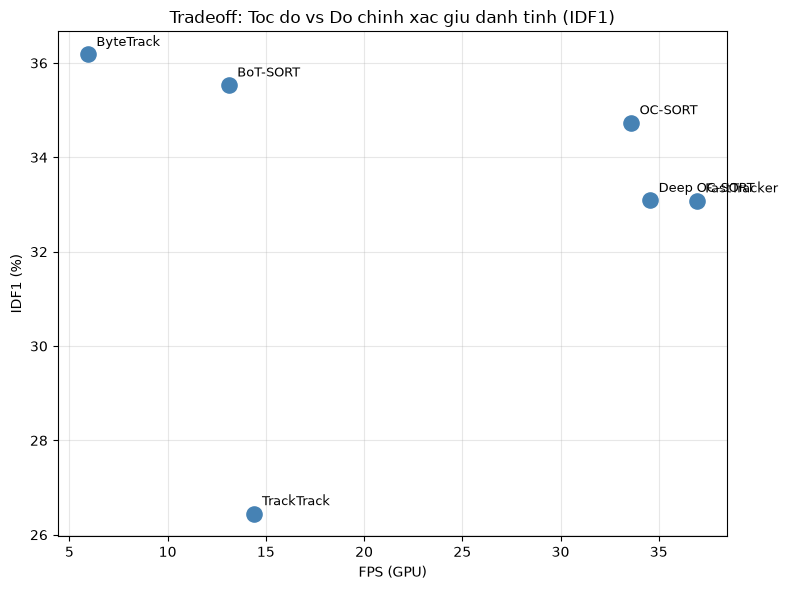

Da luu bieu do: D:\Code\Face recognition security system\ai\models\tracker_results\tracking_accuracy_vs_speed.png


In [9]:
# ===== CELL 8: Bieu do Accuracy vs FPS (scatter) =====

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(comparison_df['fps'], comparison_df['idf1'] * 100, s=120, c='steelblue')

for tracker_name in comparison_df.index:
    ax.annotate(
        tracker_name,
        (comparison_df.loc[tracker_name, 'fps'], comparison_df.loc[tracker_name, 'idf1'] * 100),
        textcoords="offset points", xytext=(6, 6), fontsize=9,
    )

device_label = 'GPU' if CUDA_OK else 'CPU'
ax.set_xlabel(f'FPS ({device_label})')
ax.set_ylabel('IDF1 (%)')
ax.set_title('Tradeoff: Toc do vs Do chinh xac giu danh tinh (IDF1)')
ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'tracking_accuracy_vs_speed.png')
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Da luu bieu do: {plot_path}")


## Buoc 4 - Bieu do so sanh chi tiet 6 tracker (MOTA/IDF1/Switch/FPS)

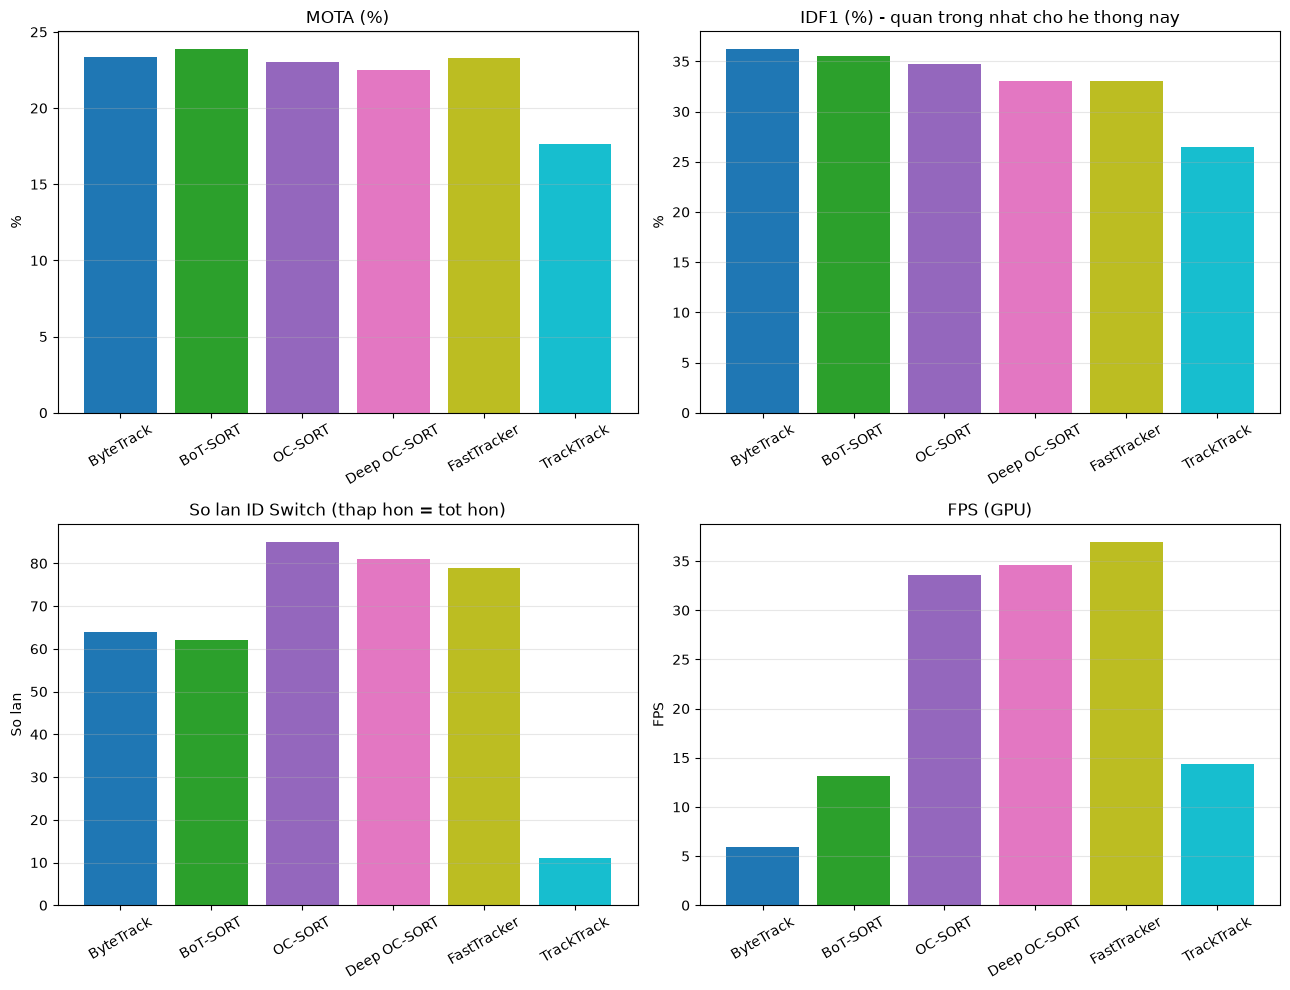

Da luu bieu do: D:\Code\Face recognition security system\ai\models\tracker_results\tracking_comparison_full.png


In [10]:
# ===== CELL 9: Ve bieu do so sanh 6 tracker =====

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

trackers = comparison_df.index.tolist()
colors = plt.cm.tab10(np.linspace(0, 1, len(trackers)))

axes[0, 0].bar(trackers, comparison_df['mota'] * 100, color=colors)
axes[0, 0].set_title('MOTA (%)')
axes[0, 0].set_ylabel('%')
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].bar(trackers, comparison_df['idf1'] * 100, color=colors)
axes[0, 1].set_title('IDF1 (%) - quan trong nhat cho he thong nay')
axes[0, 1].set_ylabel('%')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].bar(trackers, comparison_df['num_switches'], color=colors)
axes[1, 0].set_title('So lan ID Switch (thap hon = tot hon)')
axes[1, 0].set_ylabel('So lan')
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].grid(axis='y', alpha=0.3)

device_label = 'GPU' if CUDA_OK else 'CPU'
axes[1, 1].bar(trackers, comparison_df['fps'], color=colors)
axes[1, 1].set_title(f'FPS ({device_label})')
axes[1, 1].set_ylabel('FPS')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'tracking_comparison_full.png')
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Da luu bieu do: {plot_path}")


## Phu luc (tuy chon) - SCRFD + tu ghep tracker (khong dung de so sanh MOTA/IDF1)

2 ly do khong dung SCRFD cho thi nghiem chinh:
1. SCRFD tra ve box **mat**, gt.txt cua MOT17 la box **ca nguoi** -> IoU luon thap,
   MOTA/IDF1 tut khong phai vi tracker kem ma vi sai loai doi tuong so sanh.
2. SCRFD (`insightface`) khong phai model YOLO nen `model.track(tracker=...)` khong
   dung duoc - phai tu lay box roi tu goi `tracker.update()` cho tung tracker.

Phan duoi day chi de thu nghiem/do FPS, khong tinh MOTA/IDF1.


In [11]:
%pip install -q insightface onnxruntime-gpu boxmot

import insightface
import boxmot
print("insightface:", insightface.__version__)
print("boxmot:", boxmot.__version__)



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
insightface: 1.0.1
boxmot: 19.0.0


In [12]:
from insightface.app import FaceAnalysis


def load_scrfd_detector(use_gpu: bool = CUDA_OK, det_size=(640, 640)):
    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if use_gpu else ['CPUExecutionProvider']
    app = FaceAnalysis(name='buffalo_l', providers=providers)
    app.prepare(ctx_id=0 if use_gpu else -1, det_size=det_size)
    return app


def detect_faces_scrfd(app, frame_bgr, conf_thresh: float = 0.3):
    faces = app.get(frame_bgr)
    dets = [
        [*f.bbox.tolist(), float(f.det_score), 0]
        for f in faces
        if f.det_score >= conf_thresh
    ]
    return np.array(dets, dtype=np.float32) if dets else np.empty((0, 6), dtype=np.float32)


scrfd_app = load_scrfd_detector()
print("Da nap xong SCRFD (buffalo_l).")


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSI VN/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSI VN/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSI VN/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSI VN/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSI VN/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112]

## Ket luan - Doc ket qua theo dung thu tu uu tien

**Buoc 1 - Kiem tra xem viec nang detector (+ chay GPU) co giai quyet duoc goc re
khong:** so `num_matches`/`num_misses` moi voi lan chay `yolov8n` tren CPU truoc day.
Neu ty le match tang ro ret (vi du tu ~23% len >50-60% tong ground truth), xac nhan
dung chan doan - luc do so sanh giua 6 tracker moi thuc su dang tin. Neu van thap
tuong tu, can tiep tuc nang len `yolov8m` hoac xem xet lai `conf`.

**Buoc 2 - Neu do chinh xac da dang tin, doi chieu voi FPS (Buoc 3b):**
- Neu tracker co `composite_score` cao nhat (Buoc 3) **cung** co FPS chap nhan duoc
  (khong thua kem nhieu so voi ByteTrack) - chon thang do la hop ly, khong can
  danh doi gi ca.
- Neu tracker chinh xac nhat (thuong la Deep OC-SORT/TrackTrack, co ReID) cham
  hon **dang ke** - can tu hoi: he thong that co chay tren camera tinh trong nha
  khong? Neu co, huong dan chinh thuc cua Ultralytics noi ByteTrack von da phu
  hop cho truong hop nay, phan chenh lech accuracy nho co the khong dang danh
  doi lay toc do.

**Luu y quan trong ve FPS do duoc:** day la FPS cua **rieng detector+tracker**,
CHUA cong them thoi gian `insightface` (get_embedding) chay tren tung crop nguoi
trong `pipeline_runner.py` that - FPS end-to-end thuc te cua toan he thong se
THAP HON so nay, vi con phai cong them buoc nhan dien khuon mat nua. Neu chay
tren GPU, insightface (`onnxruntime`) cung can duoc chuyen sang ban GPU rieng
(`onnxruntime-gpu`) de FPS end-to-end phan anh dung tiem nang GPU - hien
`face_recognition_service.py` dang cau hinh `providers=['CPUExecutionProvider']`,
se can sua lai neu muon dung GPU cho ca phan nhan dien khuon mat.

Ghi lai tracker cuoi cung chon vao day sau khi doi chieu ca 2 chieu:
`___________________`